In [1]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
from sklearn.model_selection import train_test_split

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, average_precision_score
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"

sys.path.append(str(SRC_PATH))

In [4]:
from preprocessing import build_pipeline, clean_stroke_data
from metrics import evaluate_model, find_optimal_threshold, evaluate_model_v2

In [5]:
# set global seaborn style
sns.set_theme(
    context="notebook",
    style="ticks",
    palette="colorblind",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

## Data Cleaning

In [6]:
df = pd.read_csv("../data/raw/stroke.csv")

In [7]:
df = clean_stroke_data(df)

In [8]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,male,67.0,0,1,1,private,urban,228.69,36.6,formerly_smoked,1
1,female,61.0,0,0,1,self-employed,rural,202.21,NaN,never_smoked,1
2,male,80.0,0,1,1,private,rural,105.92,32.5,never_smoked,1
3,female,49.0,0,0,1,private,urban,171.23,34.4,smokes,1
4,female,79.0,1,0,1,self-employed,rural,174.12,24.0,never_smoked,1


## Tuning

In [9]:
X = df.drop(columns=["stroke"])
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [10]:
print("Train Stroke Rate:", y_train.mean())
print("Test Stroke Rate:", y_test.mean())

Train Stroke Rate: 0.04869097137264497
Test Stroke Rate: 0.04892367906066536


In [11]:
continuous_vars = [
    "age",
    "avg_glucose_level",
    "bmi"
]

binary_vars = [
    "hypertension",
    "heart_disease",
    "ever_married"
]

categorical_vars = [
    "gender",
    "work_type",
    "residence_type",
    "smoking_status",
]

In [12]:
pos_weight: float = (y_train == 0).sum() / (y_train == 1).sum()

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [14]:
# PR-AUC como métrica de otimização — mais informativa que ROC-AUC em datasets desbalanceados (não assume distribuição uniforme de thresholds)
scorer = "average_precision"

In [15]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

xgb_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 7],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.6, 0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.5, 1.0],
}

In [16]:
pos_weight: float = (y_train == 0).sum() / (y_train == 1).sum()
base_models = {
    "RandomForest": RandomForestClassifier(
        n_jobs=-1,
        random_state=42,
        class_weight="balanced",
    ),
    "RandomForest_SMOTETomek": RandomForestClassifier(
        n_jobs=-1,
        random_state=42,
        class_weight=None,
    ),
    "XGBoost": XGBClassifier(
        n_jobs=-1,
        scale_pos_weight=pos_weight,
        random_state=42,
        eval_metric="logloss",
    ),
    "XGBoost_SMOTETomek": XGBClassifier(
        n_jobs=-1,
        random_state=42,
        eval_metric="logloss",
    )
}

In [17]:
experiments = {
    "RandomForest": {
        "model": base_models["RandomForest"],
        "param_dist": rf_param_dist,
        "sampler": None,
    },
    "RandomForest_SMOTETomek": {
        "model": base_models["RandomForest_SMOTETomek"],
        "param_dist": rf_param_dist,
        "sampler": SMOTETomek(random_state=42),
    },
    "XGBoost": {
        "model": base_models["XGBoost"],
        "param_dist": xgb_param_dist,
        "sampler": None,
    },
    "XGBoost_SMOTETomek": {
        "model": base_models["XGBoost_SMOTETomek"],
        "param_dist": xgb_param_dist,
        "sampler": SMOTETomek(random_state=42),
    },
}


Experimento: RandomForest
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores Parâmetros:
{'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 5}
Melhor PR-AUC (CV): 0.1605
Análise de Desempenho Clínico (PR-AUC: 0.2287)

Métricas por Limiar de Decisão:
 Threshold Precision Recall F1-Score Falsos Positivos / Positivo Real
       0.1     6.40% 98.00%   0.1201                             14.6
       0.2     8.30% 84.00%   0.1511                             11.0
       0.3     9.07% 84.00%   0.1637                             10.0
       0.4     9.84% 84.00%   0.1761                              9.2
       0.5    11.59% 80.00%   0.2025                              7.6
       0.6    19.23% 70.00%   0.3017                              4.2
       0.7    27.08% 26.00%   0.2653                              2.7
       0.8     0.00%  0.00%   0.0000                              nan

------

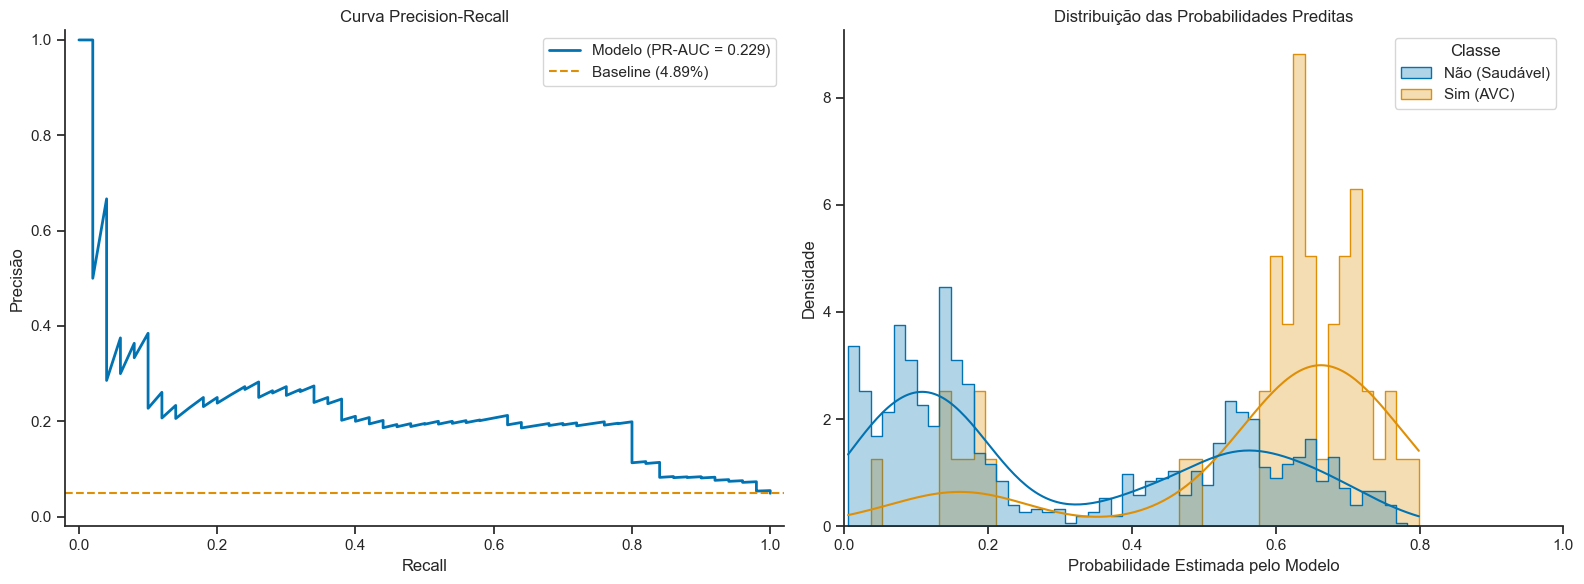


Experimento: RandomForest_SMOTETomek
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores Parâmetros:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 0.5, 'model__max_depth': 5}
Melhor PR-AUC (CV): 0.1467
Análise de Desempenho Clínico (PR-AUC: 0.1794)

Métricas por Limiar de Decisão:
 Threshold Precision Recall F1-Score Falsos Positivos / Positivo Real
       0.1     8.74% 86.00%   0.1587                             10.4
       0.2     9.19% 84.00%   0.1657                              9.9
       0.3    10.00% 84.00%   0.1787                              9.0
       0.4    11.35% 84.00%   0.2000                              7.8
       0.5    13.04% 84.00%   0.2258                              6.7
       0.6    13.77% 68.00%   0.2290                              6.3
       0.7    18.75% 36.00%   0.2466                              4.3
       0.8     0.00%  0.00%   0.0000                              nan


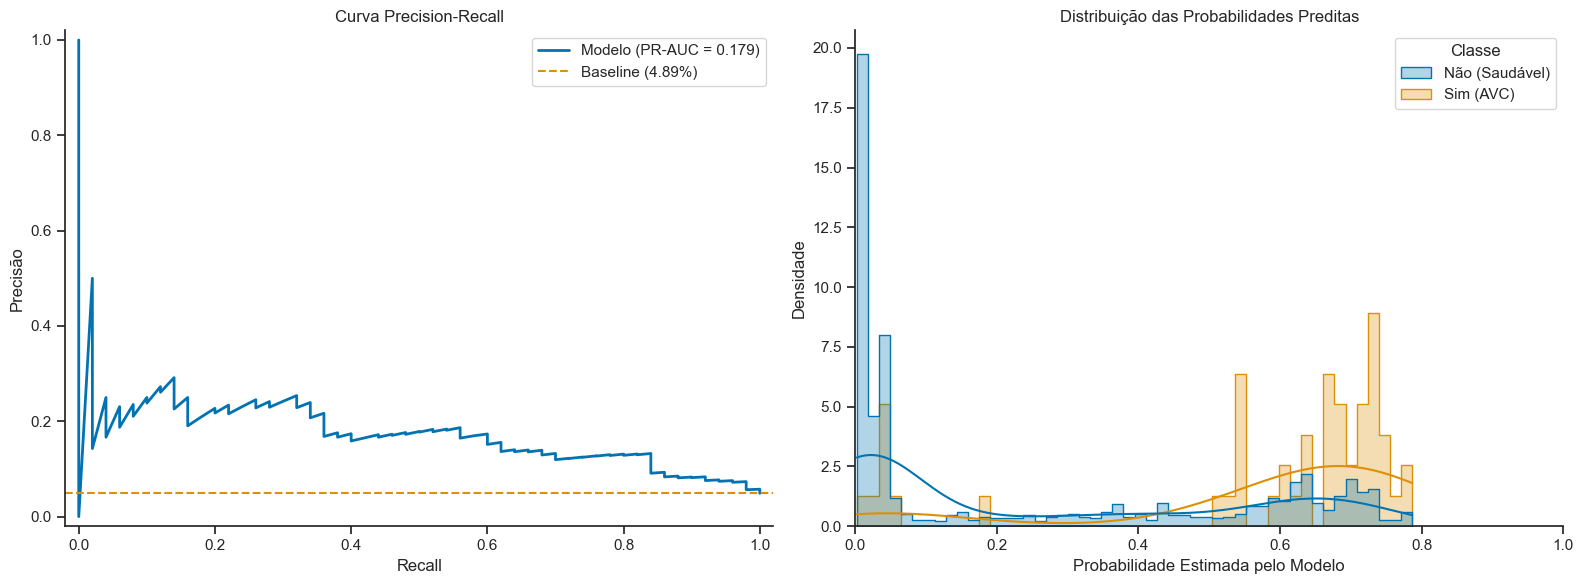


Experimento: XGBoost
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores Parâmetros:
{'model__subsample': 0.8, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.5, 'model__colsample_bytree': 0.8}
Melhor PR-AUC (CV): 0.1812
Análise de Desempenho Clínico (PR-AUC: 0.2644)

Métricas por Limiar de Decisão:
 Threshold Precision  Recall F1-Score Falsos Positivos / Positivo Real
       0.1     4.89% 100.00%   0.0933                             19.4
       0.2     5.41% 100.00%   0.1026                             17.5
       0.3     8.33%  86.00%   0.1519                             11.0
       0.4     9.05%  84.00%   0.1634                             10.0
       0.5    11.54%  84.00%   0.2029                              7.7
       0.6    18.59%  74.00%   0.2972                              4.4
       0.7    31.25%  10.00%   0.1515                              2.2
       0.8     0.00%   0.00%   0.0000                      

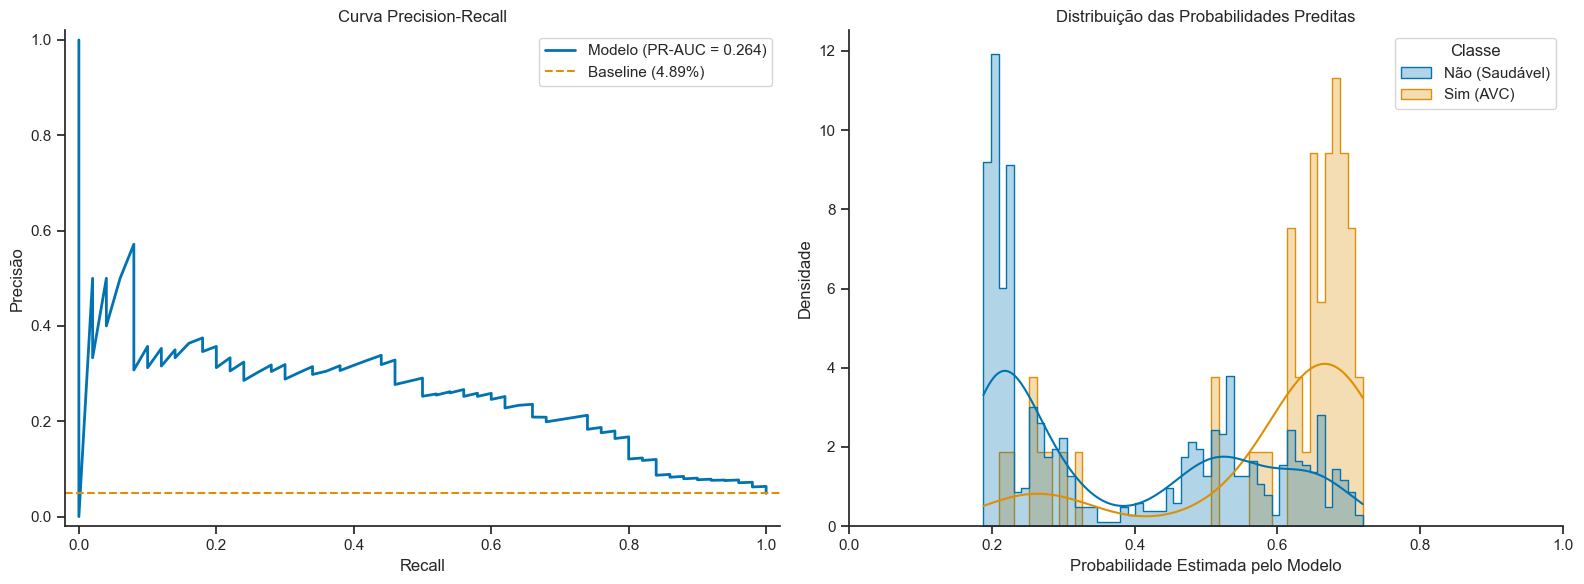


Experimento: XGBoost_SMOTETomek
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Melhores Parâmetros:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.5, 'model__colsample_bytree': 0.6}
Melhor PR-AUC (CV): 0.1598
Análise de Desempenho Clínico (PR-AUC: 0.1918)

Métricas por Limiar de Decisão:
 Threshold Precision Recall F1-Score Falsos Positivos / Positivo Real
       0.1     6.36% 98.00%   0.1195                             14.7
       0.2     8.64% 88.00%   0.1574                             10.6
       0.3     9.43% 86.00%   0.1700                              9.6
       0.4     9.90% 82.00%   0.1767                              9.1
       0.5    11.82% 78.00%   0.2053                              7.5
       0.6    18.46% 72.00%   0.2939                              4.4
       0.7    26.19% 22.00%   0.2391                              2.8
       0.8     0.00%  0.00%   0.0000                    

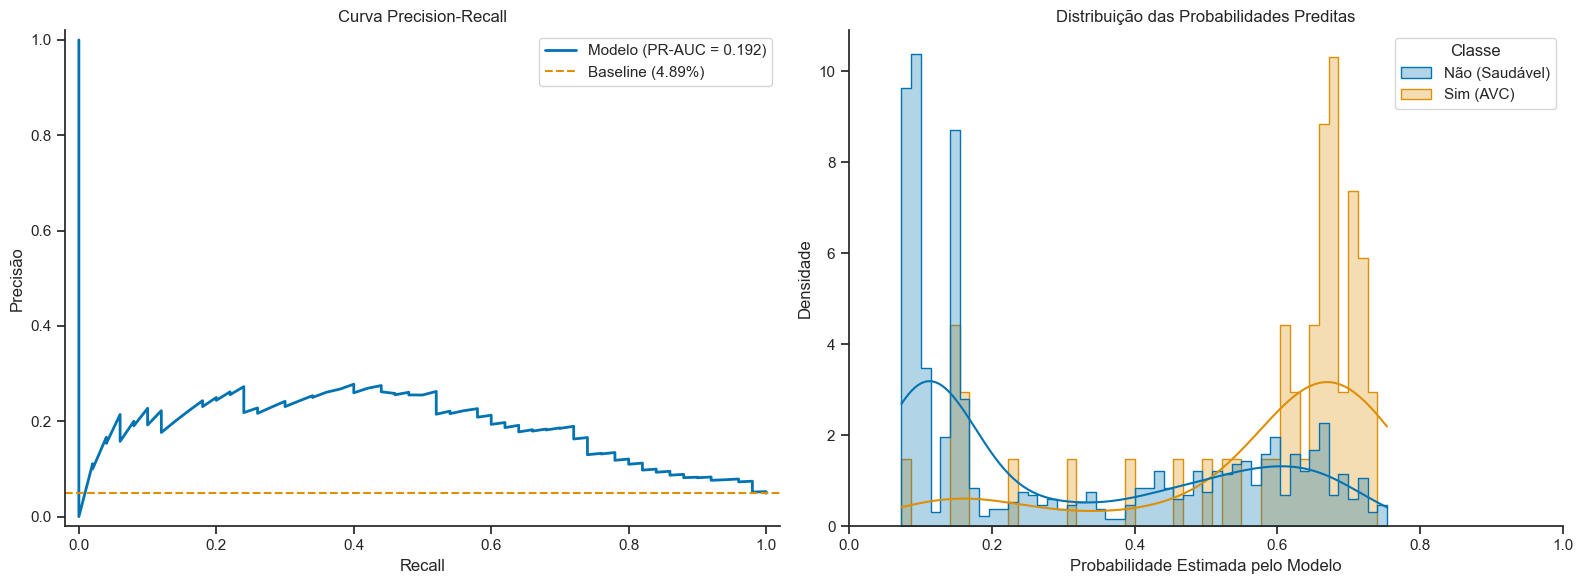

In [18]:
results = {}

for experiment_key, config in experiments.items():
    print(f"\n{'='*50}")
    print(f"Experimento: {experiment_key}")
    print(f"{'='*50}")

    pipeline = build_pipeline(
        model=config["model"],
        continuous_vars=continuous_vars,
        categorical_vars=categorical_vars,
        binary_vars=binary_vars,
        imputation_method="knn",
        apply_log=True,
        log_variables=["avg_glucose_level", "bmi"],
        sampler=config["sampler"],
    )

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config["param_dist"],
        n_iter=50,
        scoring=scorer,
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1,
        refit=True,  # re-treina com melhores params em todo X_train
    )

    search.fit(X_train, y_train)

    print("\nMelhores Parâmetros:")
    print(search.best_params_)
    print(f"Melhor PR-AUC (CV): {search.best_score_:.4f}")

    # avaliação final no X_test — único contato com holdout
    y_prob = search.best_estimator_.predict_proba(X_test)[:, 1]
    # metrics = evaluate_model(y_test, y_prob, threshold=0.5)

    pr_auc, threshold_results = evaluate_model_v2(y_test, y_prob)

    results[experiment_key] = {
        "best_params": search.best_params_,
        "cv_pr_auc": search.best_score_,
        "test_pr_auc": pr_auc,
        "threshold_results": threshold_results,
        "search": search,
    }

In [19]:
summary_list = []

for key, v in results.items():
    df_temp = v["threshold_results"].copy()

    df_temp.insert(0, "Experimento", key)
    df_temp.insert(1, "CV PR-AUC", v["cv_pr_auc"])
    df_temp.insert(2, "Test PR-AUC", v["test_pr_auc"])

    summary_list.append(df_temp)

summary = pd.concat(summary_list, ignore_index=True)

# 4. Ordena pelo poder geral do modelo (Test PR-AUC) e depois pelo threshold operacional
summary = summary.sort_values(
    by=["Test PR-AUC", "Threshold"],
    ascending=[False, True]
)

# Exibe o relatório final na tela
print(summary.to_string(index=False))

            Experimento  CV PR-AUC  Test PR-AUC  Threshold Precision  Recall F1-Score Falsos Positivos / Positivo Real
                XGBoost   0.181189     0.264376        0.1     4.89% 100.00%   0.0933                             19.4
                XGBoost   0.181189     0.264376        0.2     5.41% 100.00%   0.1026                             17.5
                XGBoost   0.181189     0.264376        0.3     8.33%  86.00%   0.1519                             11.0
                XGBoost   0.181189     0.264376        0.4     9.05%  84.00%   0.1634                             10.0
                XGBoost   0.181189     0.264376        0.5    11.54%  84.00%   0.2029                              7.7
                XGBoost   0.181189     0.264376        0.6    18.59%  74.00%   0.2972                              4.4
                XGBoost   0.181189     0.264376        0.7    31.25%  10.00%   0.1515                              2.2
                XGBoost   0.181189     0.264376 

## SHAP

In [20]:
best_pipeline = results["XGBoost"]["search"].best_estimator_

# Acessando o passo do modelo dentro do pipeline
preprocessor = best_pipeline.named_steps["model"]

preprocessor

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [21]:
import shap

c:\Personal\Projects\tcc\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
import shap
import pandas as pd

best_pipeline = results["XGBoost"]["search"].best_estimator_
preprocessor = best_pipeline.named_steps["preprocessor"]
xgb_model = best_pipeline.named_steps["model"]

# feature name extraction using the fixed pipeline
X_test_transformed = preprocessor.transform(X_test)
clean_feature_names = preprocessor.get_feature_names_out()



In [23]:
X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=clean_feature_names,
    index=X_test.index
)

# calculate shap values using the optimized tree algorithm
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_shap)

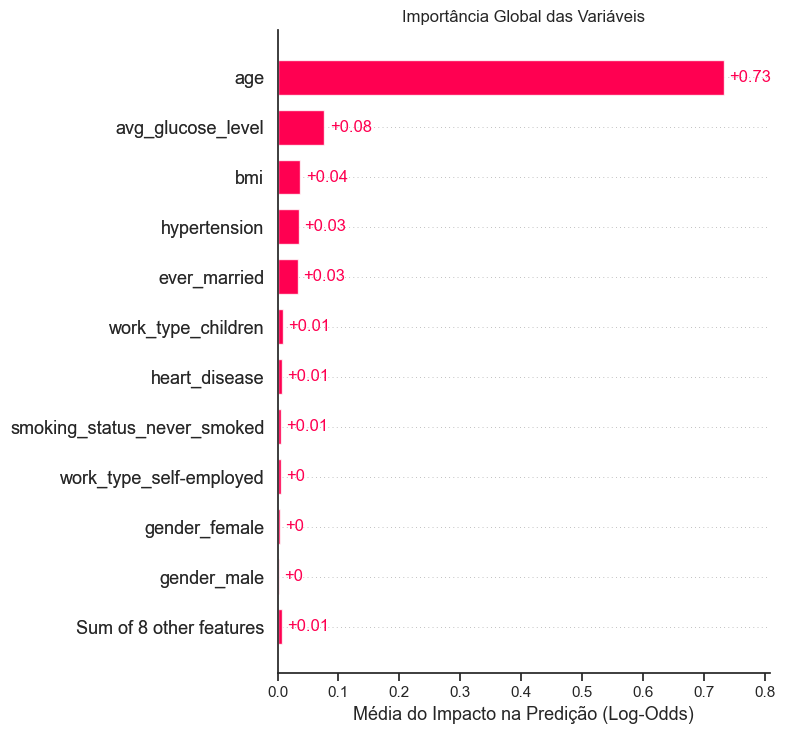

In [24]:
# global importance (bar plot)
plt.figure(figsize=(10, 7))
shap.plots.bar(shap_values, max_display=12, show=False)

ax = plt.gca()
ax.set_title("Importância Global das Variáveis")
ax.set_xlabel("Média do Impacto na Predição (Log-Odds)")

sns.despine()
plt.tight_layout()
plt.show()

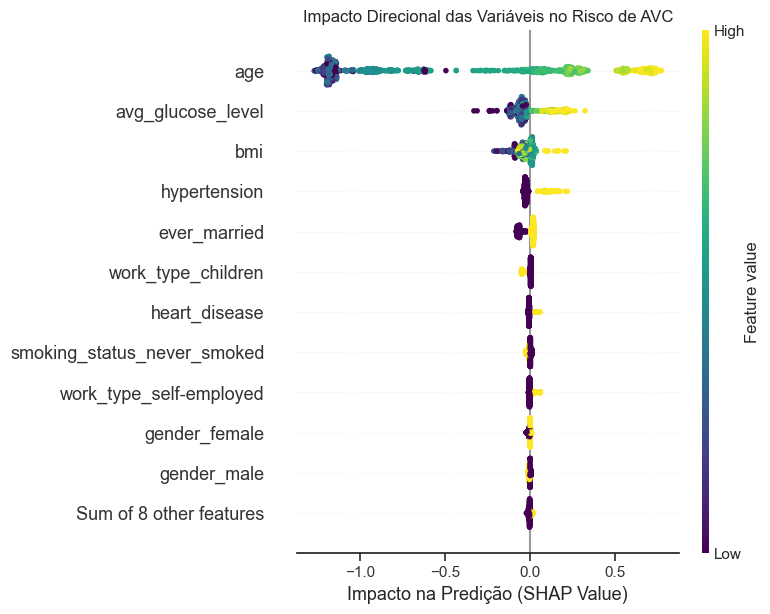

In [25]:
# directional impact (beeswarm plot)
# shows how high (red) or low (blue) values influence the prediction
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(
    shap_values,
    max_display=12,
    show=False,
    color=plt.get_cmap("viridis")
)

ax = plt.gca()
ax.set_title("Impacto Direcional das Variáveis no Risco de AVC")
ax.set_xlabel("Impacto na Predição (SHAP Value)")

plt.tight_layout()
plt.show()

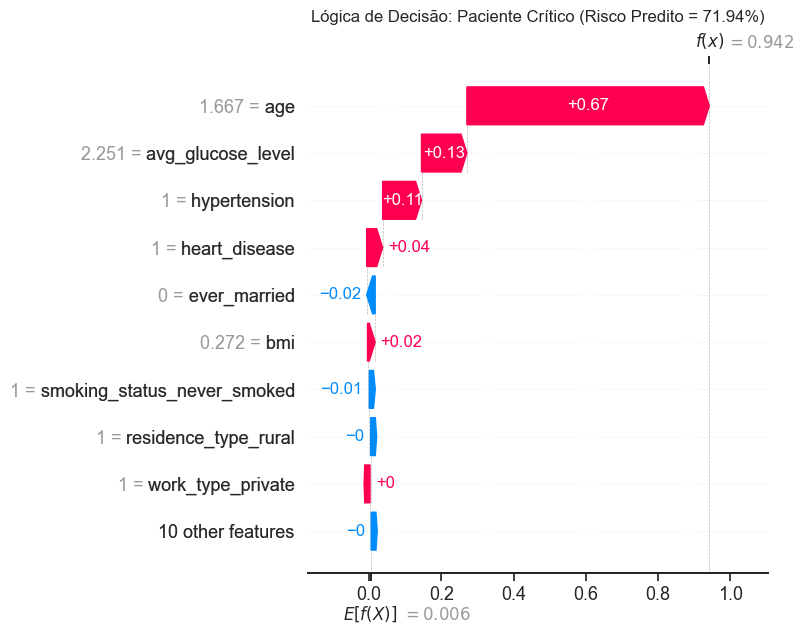

In [26]:
# local explainability (waterfall plot - critical patient)
# we use the full pipeline to ensure correct probability calculation
y_prob_test = best_pipeline.predict_proba(X_test)[:, 1]
critical_idx = np.argmax(y_prob_test)
highest_risk = y_prob_test[critical_idx]

plt.figure(figsize=(10, 6))
# passing the specific slice of shap_values for the highest risk patient
shap.plots.waterfall(
    shap_values[critical_idx],
    max_display=10,
    show=False
)

plt.title(f"Lógica de Decisão: Paciente Crítico (Risco Predito = {highest_risk:.2%})", pad=30)
ax.set_xlabel("Impacto na Predição (SHAP Value)")
plt.tight_layout()
plt.show()